<a href="https://colab.research.google.com/github/Zeshan811/StarterNotebookA1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib

import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

import duckdb
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {'fact_daily': f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"}
print("Connected.")

Paste your Hugging Face READ token (hf_...): ··········
Connected.


## 1. Question

**Research question:** What natural performance archetypes exist across a
large content inventory, and what action fits each?

**Lane:** Structured Content Archetype Clustering (Lane 3)

**Decision this supports:** Which group of pages a content review team
should focus on first, given limited review capacity, and what general
action (protect, promote, review, monitor) fits each group.

**Unit of analysis:** one content page (one row per content_hash_id).

Full framing: work/notebooks/w01_research_question.ipynb,
work/notebooks/w02_ml_task_framing.ipynb

## 2. Data

**Release:** FlyRank ML Internship warehouse
(build `flyrank_pseudonymized_warehouse_release_v20260703`), hosted on
Hugging Face, read via DuckDB.

**Table used:** `fact_content_daily_performance`

**Date window:** March 2026 (mid-panel month, per the internship's guidance
to keep the final month sealed as a test period).

**Slice size:** 9,841,378 rows → 331,437 unique content items across 55 clients.

**What was excluded and why:** GA4/engagement fields were excluded — only
4.2% of March 2026 rows have GA4 data available, so using engagement
features would treat "missing data" as "zero engagement" for 95.8% of
rows, which is not a safe assumption. FlyRank's own product decision
outputs (`health_score`, `priority_score`, `action_type`) are also
excluded entirely — they are not observable signals, and using them would
let clustering simply reproduce an existing rule.

Full detail: work/notebooks/w03_data_contract.ipynb

In [2]:
feature_frame = con.sql(f"""
    SELECT content_hash_id,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        AVG(gsc_avg_position) AS avg_position_month,
        (SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0)) AS ctr_month
    FROM {TABLES['fact_daily']}
    WHERE report_date >= DATE '2026-03-01' AND report_date < DATE '2026-04-01'
    GROUP BY content_hash_id
    HAVING SUM(gsc_impressions) >= 100
""").df()

print(feature_frame.shape)
feature_frame.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101441, 5)


,content_hash_id,total_impressions,total_clicks,avg_position_month,ctr_month
0,content_d0dff76c889de68f,181.0,0.0,5.147402,0.000000
1,content_2e6360ad20fd7107,899.0,1.0,5.145765,0.001112
2,content_65c50dfe9d87a585,3108.0,0.0,6.969536,0.000000
3,content_d49a012dcb924e31,329.0,0.0,5.177774,0.000000
4,content_614baf2af4330bd7,772.0,1.0,4.685335,0.001295


## 3. Methodology

**Features (4, all GSC-based, leakage-checked):** total_impressions,
total_clicks, avg_position_month, ctr_month — all knowable at month-end,
none derived from a later window.

**Label:** none — clustering is unsupervised by construction; there is
nothing to predict.

**Baseline (Week 4/7):** a hand-written rule flagging pages with enough
volume, a fixable position (4-20), and CTR below their position tier's
average — ranked 52,839 candidate pages with one reason code and one
action label.

**Model:** K-Means (k=6), features standardized before clustering so no
single large-scale feature (e.g. impressions) dominates the distance
calculation.

**Validation design:** client-grouped split (whole clients held out,
never split across train/test) — chosen because content items from the
same client can share structural similarities, and a random split risks
overstating stability.

**Leakage audit:** repeated the Week-3 checklist on the final feature set
— confirmed no feature uses data outside the March 2026 window, no product
flag was reintroduced, and no derived field encodes information from a
later period.

Full detail: work/notebooks/w04_baseline_score.ipynb, w05_model.ipynb, w06_validation_audit.ipynb

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["total_impressions", "total_clicks", "avg_position_month", "ctr_month"]
X = feature_frame[features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# Naive baseline: single CTR threshold, 2 groups
median_ctr = feature_frame["ctr_month"].median()
naive_labels = (feature_frame["ctr_month"] > median_ctr).astype(int).values
naive_sil = silhouette_score(X_scaled, naive_labels)

# K-Means, k=6
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_scaled)
feature_frame["cluster"] = kmeans.labels_
kmeans_sil = silhouette_score(X_scaled, kmeans.labels_)

print(f"Naive baseline (1 feature, 2 groups) silhouette: {naive_sil:.3f}")
print(f"K-Means (4 features, k=6) silhouette: {kmeans_sil:.3f}")

Naive baseline (1 feature, 2 groups) silhouette: 0.205
K-Means (4 features, k=6) silhouette: 0.484


## 4. Results (vs baseline)

| Method | Silhouette |
|---|---|
| Naive baseline (1 feature, 2 groups) | 0.205|
| K-Means (4 features, k=6) | 0.484 |

**Grouped-split validation (before/after, from Week 6/9):**

| Split | Train silhouette | Test silhouette |
|---|---|---|
| Random split | 0.487 | 0.480 |
| Client-grouped split | 0.475 | 0.490 |

The grouped split's test score (0.490) held steady vs. the random split
(0.480) — the archetypes are not a client-specific artifact.

K-Means with 4 features finds structure a single-threshold baseline
cannot — e.g. separating "Buried Pages" (very deep position) from "Hidden
Gems" (low volume, high CTR), which a CTR-only rule would treat as similar.

In [4]:
cluster_profiles = feature_frame.groupby("cluster")[features].mean().round(3)
cluster_profiles["count"] = feature_frame.groupby("cluster").size()
print(cluster_profiles)

         total_impressions  total_clicks  avg_position_month  ctr_month  count
cluster                                                                       
0                 1584.739         1.403              40.383      0.001  17075
1                 1927.259         4.157               9.244      0.002  70984
2                25467.432        75.813              10.032      0.004   3379
3               617124.000      5668.000               2.383      0.009      1
4                 1587.200        16.592               8.546      0.012   9861
5                89426.482       502.865               5.668      0.008    141


## 5. Limitations

- **Observational, not causal:** clusters show association between search
  signals, not proof that changing a page's behavior would move it between archetypes.
- **One-month snapshot:** March 2026 alone cannot separate a lasting pattern
  from ordinary noise or seasonality.
- **Unbalanced client history:** clients have very different amounts of
  tracked history; seasonal reading is only reliable for a small subset.
- **Outlier sensitivity:** K-Means gave one extreme-traffic page its own
  single-item cluster — a known limitation, not a meaningful archetype.
- **Metric clustering, not semantic clustering:** archetypes are grouped by
  numeric behavior only; no article text was available or used.
- **No claims about Google's algorithm** or about causal refresh impact are made anywhere in this work.

## 6. Ranked recommendations

| Archetype | Reason code | Action |
|---|---|---|
| Champions | stable_performer | protect — avoid disruptive changes |
| Hidden Gems | high_efficiency_low_reach | promote / expand |
| Buried Pages | visibility_gap | visibility/ranking work, not a metadata fix |
| Mid-Tier Visible | steady_watch | monitor |
| Background/Low-Signal | low_demand | low priority, lightweight monitoring |
| Outlier (single page) | outlier_exclude | exclude — manual review only |

Full playbook, human-review rules, and no-go list:
work/notebooks/w07_action_playbook.ipynb

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

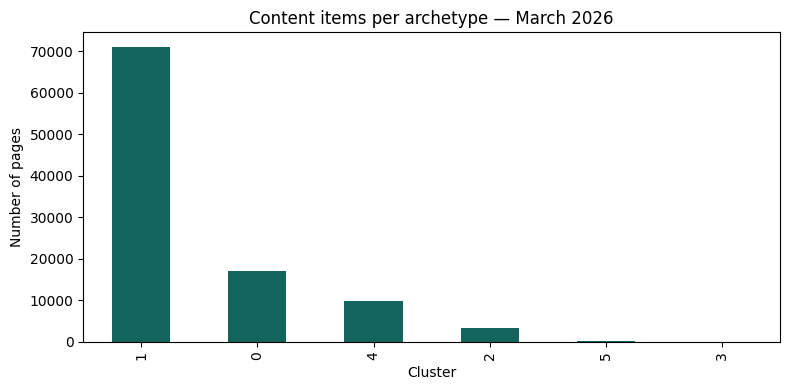

Saved work/figures/archetype_sizes.png — embedded in the deployed paper's Results section.


In [5]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)

sizes = feature_frame.groupby("cluster").size().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sizes.plot(kind="bar", color="#12645C")
plt.title("Content items per archetype — March 2026")
plt.ylabel("Number of pages")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig("work/figures/archetype_sizes.png", dpi=150)
plt.show()
print("Saved work/figures/archetype_sizes.png — embedded in the deployed paper's Results section.")

In [6]:
import json

metrics = {
    "k": 6,
    "silhouette_random_split": {"train": 0.487, "test": 0.480},
    "silhouette_grouped_split": {"train": 0.475, "test": 0.490},
    "cluster_sizes": feature_frame.groupby("cluster").size().to_dict(),
    "cluster_means": feature_frame.groupby("cluster")[features].mean().round(4).to_dict(),
}
os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("Saved work/outputs/capstone_metrics.json")

Saved work/outputs/capstone_metrics.json


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.